# LSTM 시계열 예측 실습 — 사인파 다음 값 맞히기

**LSTM(Long Short-Term Memory)** 은 순환신경망(RNN)의 한 종류로, 게이트 구조를 통해 긴 시퀀스의 장기 의존성을 학습할 수 있습니다.

이 노트북에서는 간단한 **사인파(sine wave)** 시계열을 만들고, 과거 20개 값을 보고 다음 1개 값을 예측하는 LSTM 모델을 PyTorch로 학습합니다.

## 목차
1. 라이브러리 임포트
2. 시계열 데이터 생성
3. 시퀀스(윈도우) 데이터셋 만들기
4. LSTM 모델 정의
5. 모델 학습
6. 예측 결과 시각화

## 1. 라이브러리 임포트

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 그래프 한글 깨짐 방지 (Ubuntu: NanumGothic, 없으면 다른 한글 폰트로 변경)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 고정
torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 장치:', device)

사용 장치: cuda


## 2. 시계열 데이터 생성

0~100 구간을 1000개로 쪼갠 사인파를 만들고, 여기에 **가우시안 랜덤 노이즈**(평균 0, 표준편차 0.1)를 더합니다. 실제 측정 데이터처럼 잡음이 섞이면 모델이 노이즈 속에서 진짜 패턴(사인파)을 학습해야 하므로 더 현실적인 실습이 됩니다.

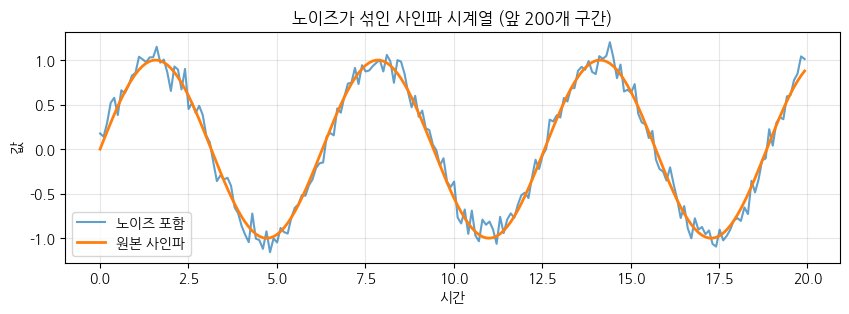

In [2]:
t = np.linspace(0, 100, 1000)
clean = np.sin(t)
noise = np.random.normal(0, 0.1, size=t.shape)   # 가우시안 노이즈
series = clean + noise

plt.figure(figsize=(10, 3))
plt.plot(t[:200], series[:200], label='노이즈 포함', alpha=0.7)
plt.plot(t[:200], clean[:200], label='원본 사인파', linewidth=2)
plt.title('노이즈가 섞인 사인파 시계열 (앞 200개 구간)')
plt.xlabel('시간'); plt.ylabel('값')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. 시퀀스(윈도우) 데이터셋 만들기

시계열 예측은 "과거 N개 → 다음 1개" 형태의 슬라이딩 윈도우로 학습 데이터를 만듭니다. 여기서는 과거 **20개(`SEQ_LEN`)** 값을 입력으로, 바로 다음 값을 정답으로 사용합니다.

LSTM 입력 텐서 형태는 `(배치, 시퀀스 길이, 특성 수)` 이며, 단변량 시계열이므로 특성 수는 1입니다. 앞 80%를 학습, 뒤 20%를 테스트로 나눕니다.

In [3]:
SEQ_LEN = 20

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X, y = make_sequences(series, SEQ_LEN)

# (샘플, 시퀀스 길이) -> (샘플, 시퀀스 길이, 특성=1)
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

n_train = int(len(X) * 0.8)
X_train, y_train = X[:n_train].to(device), y[:n_train].to(device)
X_test,  y_test  = X[n_train:].to(device), y[n_train:].to(device)

print('입력 형태 X:', X.shape)
print('학습 샘플:', len(X_train), '/ 테스트 샘플:', len(X_test))

입력 형태 X: torch.Size([980, 20, 1])
학습 샘플: 784 / 테스트 샘플: 196


## 4. LSTM 모델 정의

`nn.LSTM` 한 층(은닉 크기 32)으로 시퀀스를 처리하고, 마지막 시점의 출력을 `Linear` 층에 통과시켜 다음 값 하나를 예측합니다.

- `batch_first=True` → 입력 형태를 `(배치, 시퀀스, 특성)` 으로 둡니다.
- `out[:, -1, :]` → 시퀀스의 **마지막 시점** 은닉 상태만 사용합니다.

In [4]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # out: (배치, 시퀀스, 은닉)
        last = out[:, -1, :]           # 마지막 시점만 사용
        return self.fc(last)           # (배치, 1)

model = LSTMRegressor().to(device)
print(model)

LSTMRegressor(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 5. 모델 학습

회귀 문제이므로 손실 함수는 **MSE**, 옵티마이저는 **Adam** 을 사용합니다. 데이터가 작아 미니배치 없이 전체를 한 번에 학습(full-batch)합니다.

Epoch  20/100  train MSE: 0.018338
Epoch  40/100  train MSE: 0.017914
Epoch  60/100  train MSE: 0.016052
Epoch  80/100  train MSE: 0.014531
Epoch 100/100  train MSE: 0.013427

테스트 MSE: 0.011376


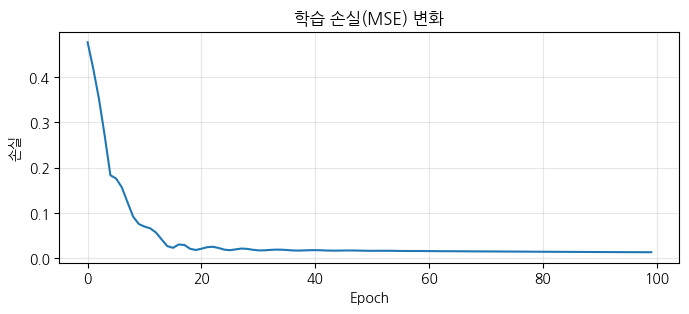

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 100
losses = []
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  train MSE: {loss.item():.6f}')

# 테스트 손실
model.eval()
with torch.no_grad():
    test_loss = criterion(model(X_test), y_test).item()
print(f'\n테스트 MSE: {test_loss:.6f}')

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title('학습 손실(MSE) 변화')
plt.xlabel('Epoch'); plt.ylabel('손실')
plt.grid(True, alpha=0.3)
plt.show()

## 6. 예측 결과 시각화

테스트 구간에서 모델 예측값과 실제값을 겹쳐 그려 얼마나 잘 따라가는지 확인합니다.

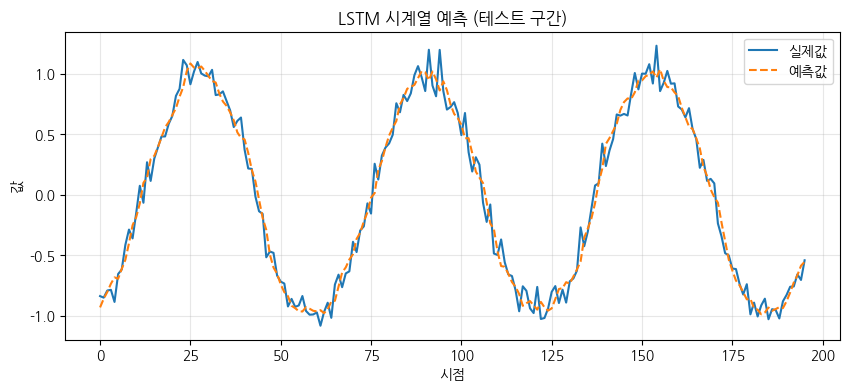

In [6]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test).cpu().numpy().ravel()
actual_test = y_test.cpu().numpy().ravel()

plt.figure(figsize=(10, 4))
plt.plot(actual_test, label='실제값')
plt.plot(pred_test, '--', label='예측값')
plt.title('LSTM 시계열 예측 (테스트 구간)')
plt.xlabel('시점'); plt.ylabel('값')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 정리

- LSTM은 **슬라이딩 윈도우**(과거 N개 → 다음 값)로 시계열 예측에 활용합니다.
- 입력 텐서는 항상 `(배치, 시퀀스 길이, 특성 수)` 3차원 형태여야 합니다.
- 마지막 시점의 은닉 상태(`out[:, -1, :]`)를 출력층에 넣어 다음 값을 예측했습니다.
- 더 발전시키려면: 다층 LSTM(`num_layers`↑), 다변량 입력, 정규화(스케일링), 미니배치 학습, 여러 스텝 예측 등을 시도해 보세요.